# Unsupervised Learning Practice — K-Means & PCA



**Part A:** K-Means Clustering
**Part B:** PCA + Clustering

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Part A: K-Means Clustering

### Step 1: Create Simple Data

We generate data with 4 visible groups, so we can check if K-Means finds them correctly.

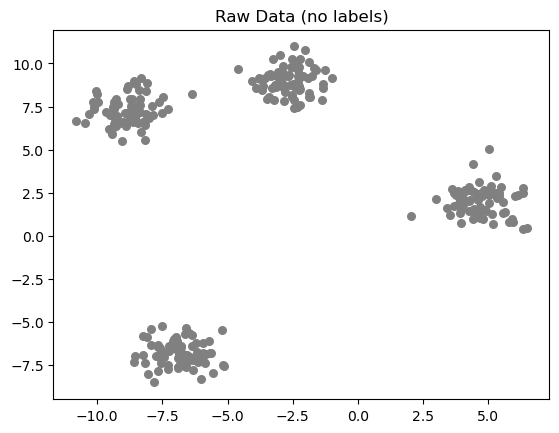

In [3]:
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title('Raw Data (no labels)')
plt.show()

### Step 2: Apply K-Means

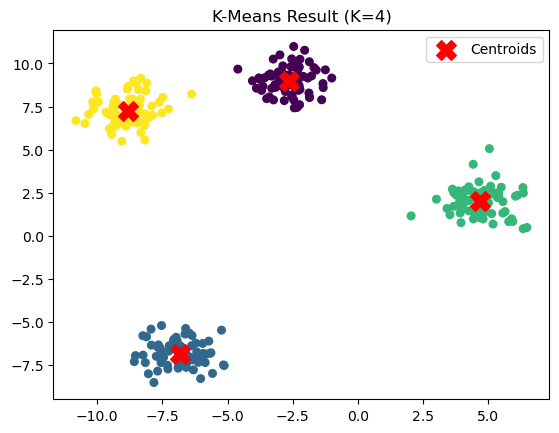

In [4]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Result (K=4)')
plt.legend()
plt.show()

Each color is a cluster K-Means found on its own. The red X marks are the centroids (cluster centers).

### Step 3: Elbow Method — Choosing K

We plot inertia (how tight the clusters are) against different K values and look for the 'elbow' bend.

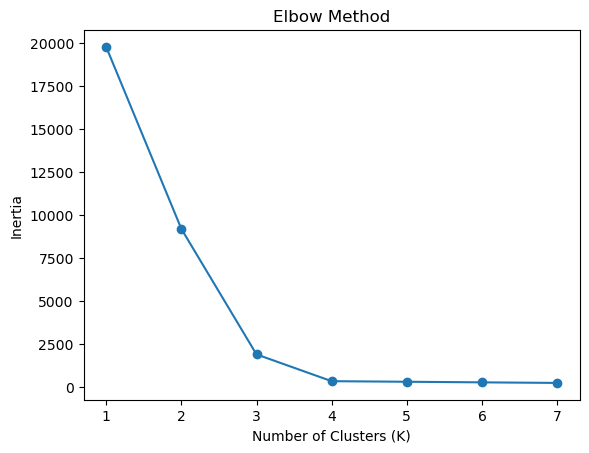

In [5]:
inertias = []
k_range = range(1, 8)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The curve bends sharply around K=4, matching the true number of groups we generated — that's the elbow.

---
## Part B: PCA + Clustering

### Step 1: Load Data

The Wine dataset has 178 samples and 13 features — too many to plot directly.

In [6]:
wine = load_wine()
X_wine = wine.data
print("Shape:", X_wine.shape)

Shape: (178, 13)


### Step 2: Scale, then Apply PCA

We reduce the 13 features down to just 2 principal components, so we can visualize the data.

In [7]:
X_wine_scaled = StandardScaler().fit_transform(X_wine)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_wine_scaled)

print(f"These 2 components explain {pca.explained_variance_ratio_.sum()*100:.1f}% of the variance")

These 2 components explain 55.4% of the variance


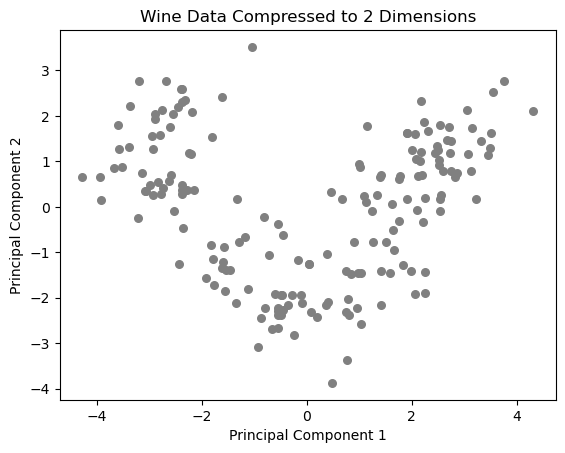

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30, color='gray')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Data Compressed to 2 Dimensions')
plt.show()

13 features are now just 2 — and you can already see natural groupings by eye, before running any clustering.

### Step 3: Cluster the PCA-Reduced Data with K-Means

d:\minconds\envs\prac_eda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


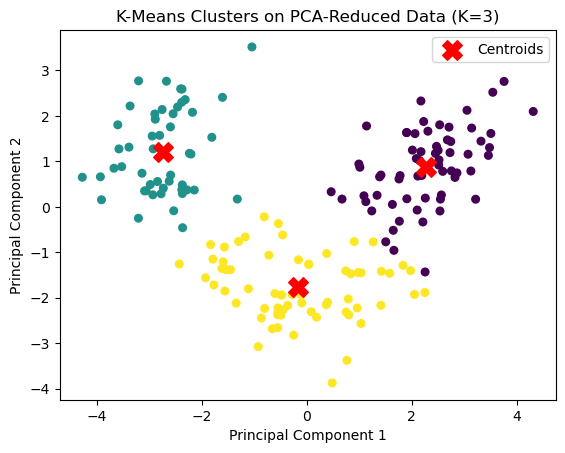

In [9]:
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_wine.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=30)
plt.scatter(kmeans_wine.cluster_centers_[:, 0], kmeans_wine.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters on PCA-Reduced Data (K=3)')
plt.legend()
plt.show()

## Summary

- **K-Means** groups unlabeled data by repeatedly assigning points to the nearest centroid, then updating the centroids. The Elbow Method helps pick the right K.
- **PCA** compresses many features down to fewer principal components while keeping most of the important information — useful for visualization.
- Combining **PCA + K-Means** let us cluster and visualize a 13-feature dataset (Wine) that we couldn't plot directly otherwise.

See `Unsupervised_Concepts.md` for the full explanation of the concepts used here.